# Pipeline de Treinamento — Previsão de `geek_rating` (BoardGameGeek)

Este notebook treina e compara 4 modelos para prever o **geek_rating** (Bayesian rating do BGG) a partir da base já tratada em `tratatamento_dados.ipynb`:

## 1. Imports

In [108]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint, uniform, loguniform
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold, ParameterSampler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42

In [64]:
# para regressão logística
cv_stratified = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# para demais modelos
cv_regression = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## 2. Carregamento dos dados

In [65]:
df = pd.read_csv("../data/bgg_dataset.csv")

print(f"Shape: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
print(f"Valores nulos totais: {df.isna().sum().sum()}")
df.head()


Shape: 25,367 linhas x 201 colunas
Valores nulos totais: 0


,geek_rating,min_suggested_age,complexity,min_players,max_players,min_time,max_time,has_description,min_suggested_age_is_missing,time_is_missing,cat_Abstract Strategy,cat_Action,cat_Adventure,cat_Ancient,cat_Animals,cat_Bluffing,cat_Card Game,cat_Children's Game,cat_City Building,cat_Civilization,cat_Deduction,cat_Dexterity,cat_Dice,cat_Economic,cat_Educational,...,desc_topic_51,desc_topic_52,desc_topic_53,desc_topic_54,desc_topic_55,desc_topic_56,desc_topic_57,desc_topic_58,desc_topic_59,desc_topic_60,desc_topic_61,desc_topic_62,desc_topic_63,desc_topic_64,desc_topic_65,desc_topic_66,desc_topic_67,desc_topic_68,desc_topic_69,desc_topic_70,desc_topic_71,desc_topic_72,desc_topic_73,desc_topic_74,desc_topic_75
0,8.394,14,3.86,2,4,60,120,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,...,-0.024344,0.007424,0.005928,0.014831,-0.005458,0.001447,0.001559,0.026275,-0.015861,-0.012888,0.014405,0.007549,-0.006247,0.022480,-0.031429,0.023186,-0.006971,0.019458,0.022354,0.006745,0.051112,-0.019974,-0.005298,-0.006523,0.003042
1,8.354,14,3.80,1,4,90,150,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,...,0.007720,0.019655,0.000066,-0.002710,0.016711,0.013866,-0.009986,-0.022435,0.015682,0.015995,-0.012528,-0.022299,-0.016768,0.027525,-0.006174,0.011502,0.006608,-0.015206,0.019912,0.005453,0.006507,-0.005784,0.011518,0.021333,-0.010052
2,8.345,13,2.83,2,4,60,60,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,-0.012816,-0.014782,-0.025753,-0.009858,0.027082,0.041514,0.016739,-0.005158,-0.036144,0.016003,0.022284,0.026519,0.028645,-0.010552,-0.000457,-0.011320,-0.040158,0.024342,-0.035386,-0.004539,0.010960,-0.017993,0.010784,-0.017054,0.017555
3,8.296,14,3.92,1,4,60,120,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,...,-0.025500,0.000277,0.012988,0.079161,-0.126748,0.044902,-0.093450,0.007921,-0.031752,0.013904,0.049051,-0.052386,-0.010065,0.101284,0.002104,-0.055705,0.000096,0.032313,0.018581,0.040011,0.041790,-0.033725,0.053397,0.011585,-0.001179
4,8.244,13,3.52,1,6,60,120,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,-0.013324,0.043047,0.000535,0.052425,-0.008044,0.015341,-0.022738,-0.011953,-0.043263,0.007040,0.047292,0.034955,-0.070503,-0.018493,0.005414,-0.024387,-0.020646,0.007575,0.061679,0.000379,0.123206,-0.034931,0.116201,0.072021,0.071281


In [66]:
df["geek_rating"].describe()


count    25367.000000
mean         5.693836
std          0.371549
min          5.268000
25%          5.507000
50%          5.529000
75%          5.699000
max          8.483000
Name: geek_rating, dtype: float64

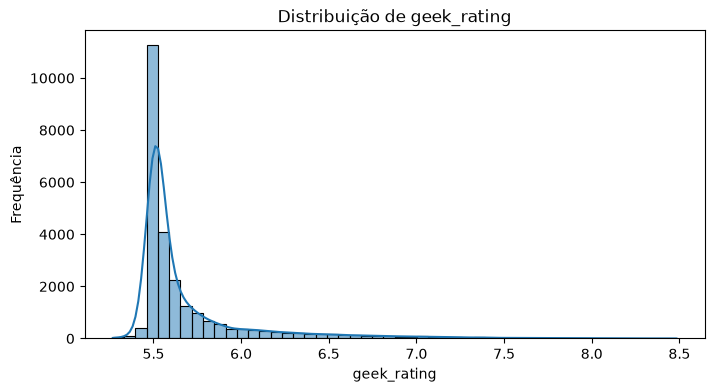

In [67]:
plt.figure(figsize=(8, 4))
sns.histplot(df["geek_rating"], bins=50, kde=True)
plt.title("Distribuição de geek_rating")
plt.xlabel("geek_rating")
plt.ylabel("Frequência")
plt.show()


**Observação importante sobre a distribuição:** o `geek_rating` é fortemente assimétrico à direita. A maioria dos jogos se concentra perto do "piso" do Bayesian average do BGG (em torno de 5.5), e poucos jogos atingem ratings altos (>7.5). Isso afeta diretamente a versão de classificação (Regressão Logística): as faixas mais altas terão poucas amostras, o que é esperado e será discutido nos resultados.

## 3. Separação de features e targets

- `X`: todas as colunas exceto `geek_rating`.
- `y_reg`: o `geek_rating` contínuo (usado em Regressão Linear, Random Forest e Gradient Boosting).
- O target de classificação (`y_clf`) será derivado de `y_reg` *depois* do split treino/teste, para não vazar informação do teste na definição das faixas.

In [68]:
X = df.drop(columns=["geek_rating"])
y_reg = df["geek_rating"]

print(f"X: {X.shape}")
print(f"y_reg: {y_reg.shape}")


X: (25367, 200)
y_reg: (25367,)


## 4. Split treino/teste

Usamos `train_test_split` com 80% treino / 20% teste. Como as features já vêm padronizadas (RobustScaler) e codificadas do notebook de normalização, não há necessidade de pré-processamento adicional aqui.

In [69]:
# dividindo o conjunto em 70% treino, e 30% teste (temporário)
X_train, X_temp, y_train_reg, y_temp_reg = train_test_split(
    X,
    y_reg,
    test_size=0.30,
    random_state=RANDOM_STATE
)

# divide os 30% em 15% validação e 15% teste
X_val, X_test, y_val_reg, y_test_reg = train_test_split(
    X_temp,
    y_temp_reg,
    test_size=0.50,
    random_state=RANDOM_STATE
)

print("Treino:", X_train.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)


Treino: (17756, 200)
Validação: (3805, 200)
Teste: (3806, 200)


## 5. Discretização do target para a Regressão Logística


In [70]:
N_BINS = 5

# Cria classes balanceadas a partir do treino
y_train_clf, bin_edges = pd.qcut(
    y_train_reg,
    q=N_BINS,
    labels=False,
    retbins=True,
    duplicates='drop'
)

# Abre as extremidades
bin_edges[0] = -np.inf
bin_edges[-1] = np.inf

# Aplica exatamente os mesmos limites
y_val_clf = pd.cut(
    y_val_reg,
    bins=bin_edges,
    labels=False,
    include_lowest=True
)

y_test_clf = pd.cut(
    y_test_reg,
    bins=bin_edges,
    labels=False,
    include_lowest=True
)

In [71]:
print("Faixas criadas:")

for i in range(len(bin_edges)-1):
    print(
        f"Classe {i}: "
        f"{bin_edges[i]:.3f} até {bin_edges[i+1]:.3f}"
    )

Faixas criadas:
Classe 0: -inf até 5.503
Classe 1: 5.503 até 5.520
Classe 2: 5.520 até 5.572
Classe 3: 5.572 até 5.774
Classe 4: 5.774 até inf


In [72]:
print(y_train_clf.value_counts().sort_index())
print(y_val_clf.value_counts().sort_index())
print(y_test_clf.value_counts().sort_index())

geek_rating
0    3741
1    3531
2    3418
3    3526
4    3540
Name: count, dtype: int64
geek_rating
0    781
1    726
2    745
3    771
4    782
Name: count, dtype: int64
geek_rating
0    816
1    759
2    694
3    771
4    766
Name: count, dtype: int64


             treino  teste
geek_rating               
0              3741    816
1              3531    759
2              3418    694
3              3526    771
4              3540    766


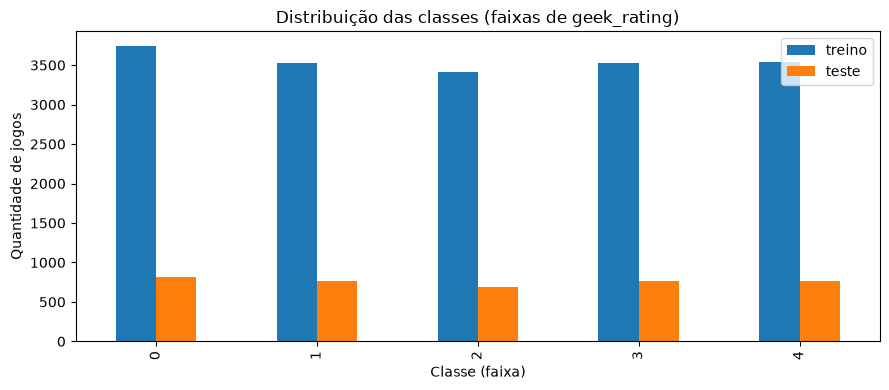

In [73]:
dist_treino = y_train_clf.value_counts().sort_index()
dist_teste = y_test_clf.value_counts().sort_index()

dist_df = pd.DataFrame({"treino": dist_treino, "teste": dist_teste}).fillna(0).astype(int)
print(dist_df)

plt.figure(figsize=(9, 4))
dist_df.plot(kind="bar", ax=plt.gca())
plt.title("Distribuição das classes (faixas de geek_rating)")
plt.xlabel("Classe (faixa)")
plt.ylabel("Quantidade de jogos")
plt.tight_layout()
plt.show()


## 6. Função auxiliar de avaliação (regressão)

Função utilitária para reportar RMSE, MAE e R² de forma consistente entre os 3 modelos de regressão.

In [ ]:
def avaliar_regressao(nome_modelo, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5 # qual é a magnitude do erro, penalizando severamente os erros maiores?
    mae = mean_absolute_error(y_test, y_pred) # em média, o quão distante a previsão está do valor real?
    r2 = r2_score(y_test, y_pred)

    print(f"--- {nome_modelo} ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")

    return {"modelo": nome_modelo, "RMSE": rmse, "MAE": mae, "R2": r2}


## 7. Modelo 1 — Regressão Linear Múltipla

In [75]:
# Criando o Pipeline
pipeline_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

t0 = time.time()

modelo_linear = pipeline_linear.fit(X_train, y_train_reg)

print(f"Tempo de treinamento: {time.time() - t0:.1f}s")

Tempo de treinamento: 0.2s


In [91]:
y_pred = modelo_linear.predict(X_test)

residuos = y_test_reg - y_pred

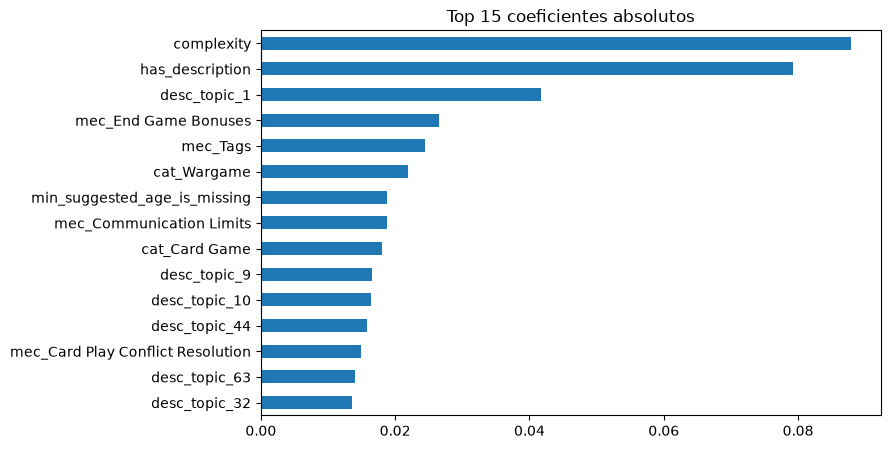

In [95]:
modelo_lr = modelo_linear.named_steps['model']

coef = pd.Series(
    modelo_lr.coef_,
    index=X_train.columns
)

top15 = (
    coef.abs()
        .sort_values(ascending=False)
        .head(15)
)

plt.figure(figsize=(8,5))

top15.sort_values().plot(kind="barh")

plt.title("Top 15 coeficientes absolutos")

plt.show()

In [76]:
resultado_linear = avaliar_regressao("Regressão Linear", modelo_linear, X_test, y_test_reg)


--- Regressão Linear ---
RMSE: 0.3096
MAE:  0.1937
R²:   0.3112


## 8. Modelo 2 — Random Forest Regressor

Random Forest costuma capturar bem relações não-lineares entre as features (ex: número de votos, complexidade, categorias) e o `geek_rating`.

In [ ]:
pipeline_rf = Pipeline([
    ('model', RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=1
    ))
])

best_score = -np.inf
best_params = None
best_model = None

param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 
for params in ParameterSampler(
    param_dist_rf,
    n_iter=20,
    random_state=RANDOM_STATE
):

    model = RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **params
    )

    model.fit(X_train, y_train_reg)

    pred_val = model.predict(X_val)

    score = r2_score(y_val_reg, pred_val)

    if score > best_score:
        best_score = score
        best_params = params
        best_model = model

print(best_score)
print(best_params)

0.3496577524656812
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 30}


In [ ]:
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train_reg, y_val_reg])

cv_scores = cross_val_score(
    RandomForestRegressor(random_state=RANDOM_STATE, **best_params),
    X_train_final, y_train_final,
    cv=5, scoring='r2', n_jobs=-1
)
print(f"R² (CV 5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

final_model = RandomForestRegressor(
    random_state=RANDOM_STATE,
    **best_params
)

final_model.fit(
    X_train_final,
    y_train_final
)
resultado_rf = avaliar_regressao("Random Forest", final_model, X_test, y_test_reg)

R² (CV 5-fold): 0.3705 ± 0.0232


In [ ]:
def plot_diagnostico_regressao(nome_modelo, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    residuos = y_test - y_pred

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].scatter(y_test, y_pred, alpha=0.5)
    axes[0].plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--'
    )
    axes[0].set_xlabel("Valor real")
    axes[0].set_ylabel("Valor predito")
    axes[0].set_title(f"{nome_modelo}: Predito vs Real")

    axes[1].hist(residuos, bins=30, edgecolor='black')
    axes[1].set_title(f"{nome_modelo}: Distribuição dos resíduos")
    axes[1].set_xlabel("Resíduo")

    plt.tight_layout()
    plt.show()

plot_diagnostico_regressao("Random Forest", final_model, X_test, y_test_reg)

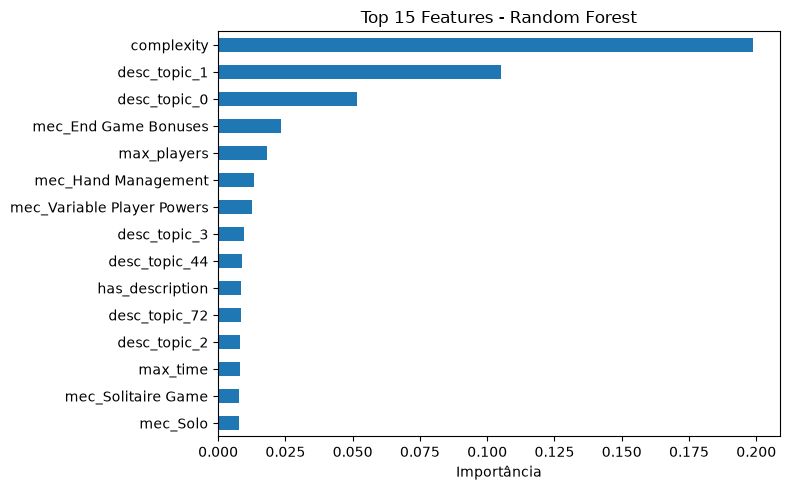

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

modelo_rf = final_model

importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X_train.columns
)

top15 = importancias.sort_values(
    ascending=False
).head(15)

plt.figure(figsize=(8,5))
top15.sort_values().plot(kind="barh")
plt.title("Top 15 Features - Random Forest")
plt.xlabel("Importância")
plt.tight_layout()
plt.show()

## 9. Modelo 3 — Gradient Boosting Regressor

Gradient Boosting ajusta árvores sequencialmente, cada uma corrigindo os erros da anterior. Tende a ter desempenho competitivo, ao custo de mais tempo de treino.

In [81]:
pipeline_gb = Pipeline([
    ('model', GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ))
])

param_dist_gb = {
    "n_estimators": randint(50, 300),

    "learning_rate": uniform(loc=0.01, scale=0.15),

    "max_depth": randint(2, 6),

    "subsample": uniform(loc=0.7, scale=0.3),

    "min_samples_split": randint(2, 10),

    "min_samples_leaf": randint(1, 5)
}

t0 = time.time()

best_score = -np.inf
best_params = None
best_model = None

for params in ParameterSampler(
    param_dist_gb,
    n_iter=20,
    random_state=RANDOM_STATE
):

    model = GradientBoostingRegressor(
        random_state=RANDOM_STATE,
        **params
    )

    model.fit(X_train, y_train_reg)

    pred_val = model.predict(X_val)

    score = r2_score(y_val_reg, pred_val)

    if score > best_score:
        best_score = score
        best_params = params
        best_model = model

print(f"Tempo de treinamento: {time.time() - t0:.1f}s")
print(best_score)
print(best_params)

Tempo de treinamento: 1300.7s
0.36046330555788564
{'learning_rate': np.float64(0.06927253540027216), 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 8, 'n_estimators': 97, 'subsample': np.float64(0.7979622306417505)}


In [82]:
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train_reg, y_val_reg])

final_model = GradientBoostingRegressor(
    random_state=RANDOM_STATE,
    **best_params
)

final_model.fit(
    X_train_final,
    y_train_final
)
resultado_gb = avaliar_regressao("Gradient Boosting", final_model, X_test, y_test_reg)

--- Gradient Boosting ---
RMSE: 0.2963
MAE:  0.1698
R²:   0.3689


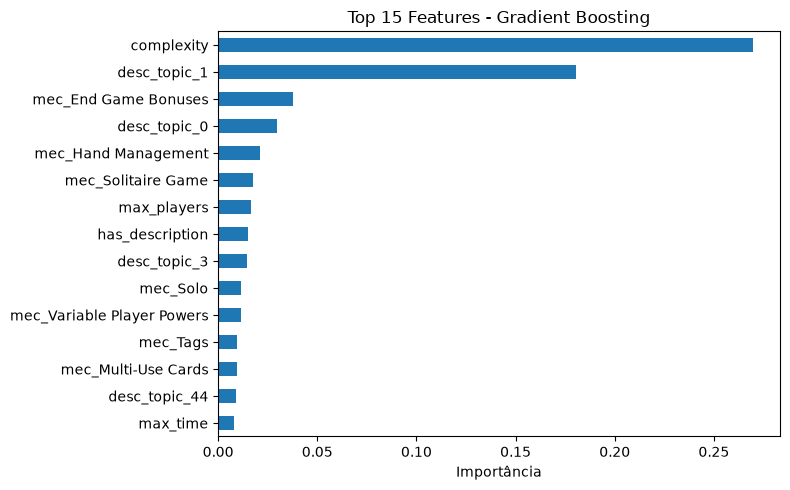

In [83]:
modelo_gb = final_model

importancias = pd.Series(
    modelo_gb.feature_importances_,
    index=X_train.columns
)

top15 = importancias.sort_values(
    ascending=False
).head(15)

plt.figure(figsize=(8,5))
top15.sort_values().plot(kind="barh")
plt.title("Top 15 Features - Gradient Boosting")
plt.xlabel("Importância")
plt.tight_layout()
plt.show()

In [ ]:
# modelo_gb = random_search_gb.best_estimator_
# resultado_gb = avaliar_regressao("Gradient Boosting", modelo_gb, X_test, y_test_reg)


--- Gradient Boosting ---
RMSE: 0.2973
MAE:  0.1714
R²:   0.3270


## 10. Modelo 4 — Regressão Logística (classificação em 10 faixas)

In [84]:
# pipeline_logistic = Pipeline([
#     ('scaler', StandardScaler()),
#     ('model', LogisticRegression(
#         random_state=RANDOM_STATE,
#         max_iter=5000
#     ))
# ])

param_dist_log = {
    "model__C": loguniform(1e-3, 1e2),
    "model__penalty": [None, "l2"],
}

best_score = -np.inf
best_params = None
best_model = None

for params in ParameterSampler(
    param_dist_log,
    n_iter=20,
    random_state=RANDOM_STATE
):

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=5000,
            solver='saga'
        ))
    ])

    model.set_params(**params)

    model.fit(
        X_train,
        y_train_clf
    )

    pred_val = model.predict(X_val)

    score = f1_score(
        y_val_clf,
        pred_val,
        average='weighted'
    )

    if score > best_score:
        best_score = score
        best_params = params
        best_model = model

print("Melhor F1:", best_score)
print("Melhores parâmetros:", best_params)

c:\Users\luiza\Documents\repo\trabalho_final_aprendizado_maq\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\luiza\Documents\repo\trabalho_final_aprendizado_maq\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1443: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\luiza\Documents\repo\trabalho_final_aprendizado_maq\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default val

Melhor F1: 0.36907714154050153
Melhores parâmetros: {'model__C': np.float64(0.008263688714158009), 'model__penalty': 'l2'}


In [85]:
type(y_train_clf)
type(y_val_clf)

pandas.Series

In [86]:
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train_clf, y_val_clf])

modelo_logistic = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=5000
    ))
])

modelo_logistic.set_params(**best_params)

modelo_logistic.fit(
    X_train_final,
    y_train_final
)

y_pred_clf = modelo_logistic.predict(X_test)

c:\Users\luiza\Documents\repo\trabalho_final_aprendizado_maq\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [87]:
modelo_logistic = best_model

y_pred_clf = modelo_logistic.predict(X_test)

acc = accuracy_score(
    y_test_clf,
    y_pred_clf
)

f1_weighted = f1_score(
    y_test_clf,
    y_pred_clf,
    average="weighted"
)

precision_weighted = precision_score(
    y_test_clf,
    y_pred_clf,
    average="weighted",
    zero_division=0
)

recall_weighted = recall_score(
    y_test_clf,
    y_pred_clf,
    average="weighted",
    zero_division=0
)

print("--- Regressão Logística (5 classes por quantis) ---")
print(f"Accuracy:              {acc:.4f}")
print(f"F1 (weighted):         {f1_weighted:.4f}")
print(f"Precision (weighted):  {precision_weighted:.4f}")
print(f"Recall (weighted):     {recall_weighted:.4f}")
print()

print(classification_report(
    y_test_clf,
    y_pred_clf,
    zero_division=0
))

--- Regressão Logística (5 classes por quantis) ---
Accuracy:              0.3986
F1 (weighted):         0.3712
Precision (weighted):  0.3768
Recall (weighted):     0.3986

              precision    recall  f1-score   support

           0       0.44      0.64      0.52       816
           1       0.27      0.21      0.24       759
           2       0.38      0.17      0.23       694
           3       0.32      0.25      0.28       771
           4       0.47      0.69      0.56       766

    accuracy                           0.40      3806
   macro avg       0.38      0.39      0.37      3806
weighted avg       0.38      0.40      0.37      3806



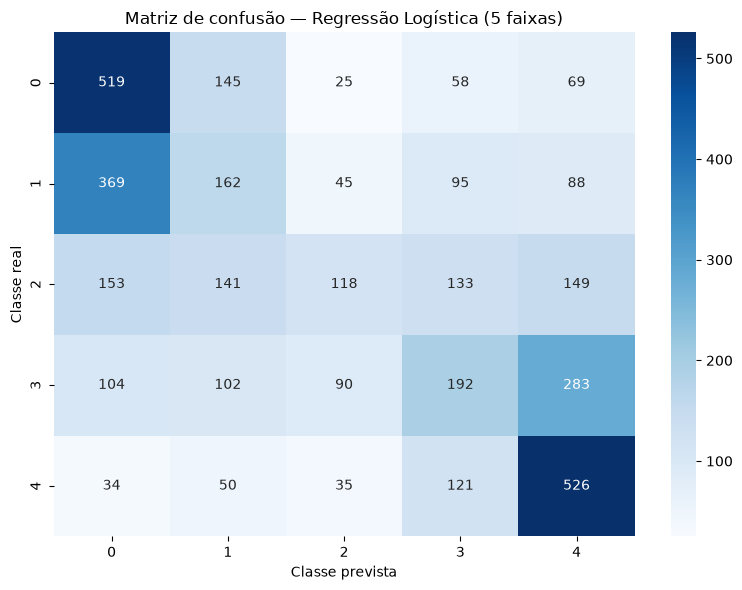

In [88]:
cm = confusion_matrix(y_test_clf, y_pred_clf, labels=range(N_BINS))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(N_BINS), yticklabels=range(N_BINS))
plt.title("Matriz de confusão — Regressão Logística (5 faixas)")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.tight_layout()
plt.show()


In [89]:
resultado_logistic = {
    "modelo": "Regressão Logística (10 classes)",
    "Accuracy": acc,
    "F1_weighted": f1_weighted,
    "Precision_weighted": precision_weighted,
    "Recall_weighted": recall_weighted,
}


## 11. Comparação final dos modelos

Como a Regressão Logística resolve um problema diferente (classificação em 10 faixas, e não regressão contínua), reportamos suas métricas separadamente das métricas de regressão (RMSE, MAE, R²) dos outros 3 modelos.

In [ ]:
tabela_regressao = pd.DataFrame([resultado_linear, resultado_rf, resultado_gb]).set_index("modelo")
tabela_regressao = tabela_regressao.sort_values("R2", ascending=False)
print("Comparação — Modelos de Regressão (target contínuo)")
tabela_regressao


NameError: name 'resultado_gb' is not defined

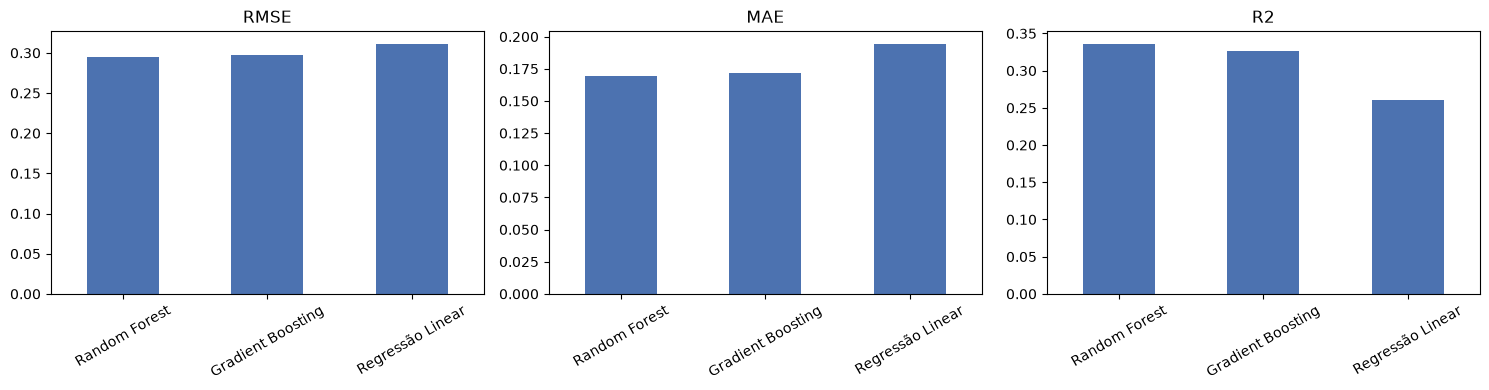

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metrica in zip(axes, ["RMSE", "MAE", "R2"]):
    tabela_regressao[metrica].plot(kind="bar", ax=ax, color="#4C72B0")
    ax.set_title(metrica)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


In [ ]:
tabela_classificacao = pd.DataFrame([resultado_logistic]).set_index("modelo")
print("Resultado — Regressão Logística (target discretizado em 10 faixas)")
tabela_classificacao


Resultado — Regressão Logística (target discretizado em 10 faixas)


,Accuracy,F1_weighted,Precision_weighted,Recall_weighted
modelo,,,,
Regressão Logística (10 classes),0.482854,0.539911,0.623498,0.482854


## 12. Resumo dos melhores hiperparâmetros encontrados (GridSearchCV)

In [ ]:
resumo_hiperparametros = pd.DataFrame([
    {"modelo": "Regressão Linear", "melhores_hiperparametros": grid_linear.best_params_, "score_cv": grid_linear.best_score_, "metrica_cv": "R2"},
    {"modelo": "Random Forest", "melhores_hiperparametros": random_search_rf.best_params_, "score_cv": random_search_rf.best_score_, "metrica_cv": "R2"},
    {"modelo": "Gradient Boosting", "melhores_hiperparametros": random_search_gb.best_params_, "score_cv": random_search_gb.best_score_, "metrica_cv": "R2"},
    {"modelo": "Regressão Logística", "melhores_hiperparametros": random_search_log.best_params_, "score_cv": random_search_log.best_score_, "metrica_cv": "F1_weighted"},
])
resumo_hiperparametros


,modelo,melhores_hiperparametros,score_cv,metrica_cv
0,Regressão Linear,"{'model__fit_intercept': True, 'model__positiv...",0.308396,R2
1,Random Forest,"{'model__max_depth': None, 'model__min_samples...",0.378124,R2
2,Gradient Boosting,"{'model__learning_rate': 0.1, 'model__max_dept...",0.372948,R2
3,Regressão Logística,"{'model__C': 0.01, 'model__solver': 'lbfgs'}",0.547198,F1_weighted
